In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("shape : ", data.shape,"\n")
data.info()


shape :  (7043, 21) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [5]:
data.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:

#correcting totalcharges data type
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

missing count : 
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


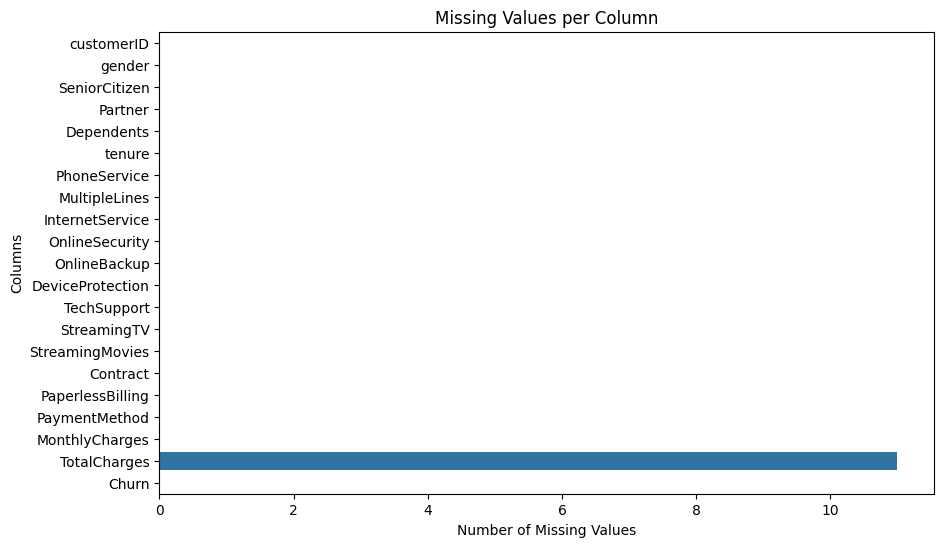

In [7]:
#finding missing values
missing = data.isnull().sum()
print("missing count : \n",missing)
plt.figure(figsize=(10,6))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()


In [8]:
#fixing missing values
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
print("missing total charges : ",data["TotalCharges"].isnull().sum())

missing total charges :  0


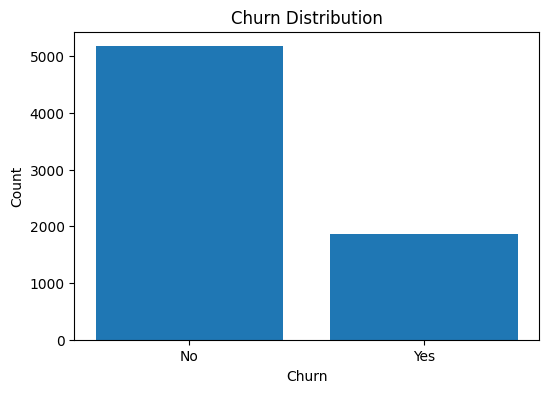

In [9]:
plt.figure(figsize=(6,4))

# Get churn counts
churn_counts = data["Churn"].value_counts()

# Bar chart
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

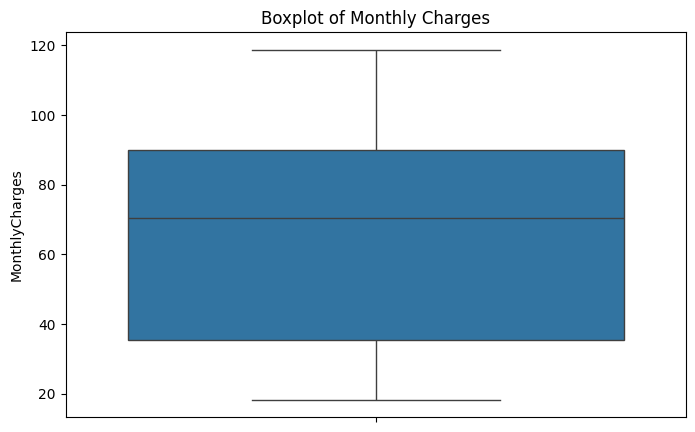

MonthlyCharges outliers: 0


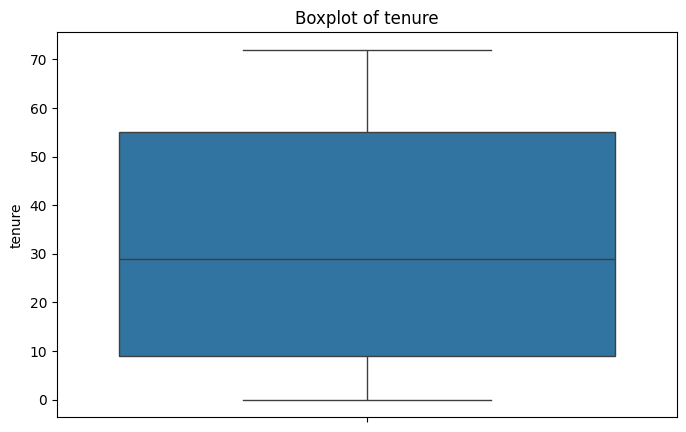

tenure outliers: 0


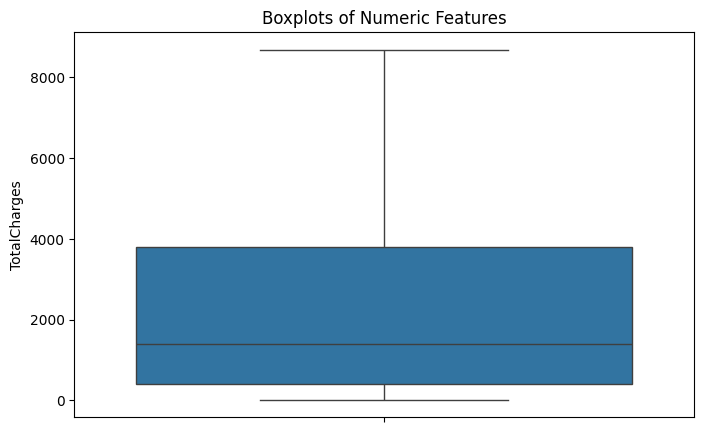

TotalCharges outliers: 0


In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data["MonthlyCharges"],showfliers=True, fliersize=2)
plt.title("Boxplot of Monthly Charges")
plt.show()

Q1 = data['MonthlyCharges'].quantile(0.25)
Q3 = data['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['MonthlyCharges'] < Q1 - 1.5*IQR) | (data['MonthlyCharges'] > Q3 + 1.5*IQR)]
print("MonthlyCharges outliers:", len(outliers))

plt.figure(figsize=(8,5))
sns.boxplot(data=data["tenure"],showfliers=True, fliersize=2)
plt.title("Boxplot of tenure")
plt.show()

Q1 = data['tenure'].quantile(0.25)
Q3 = data['tenure'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['tenure'] < Q1 - 1.5*IQR) | (data['tenure'] > Q3 + 1.5*IQR)]
print("tenure outliers:", len(outliers))

plt.figure(figsize=(8,5))
sns.boxplot(data=data["TotalCharges"],showfliers=True, fliersize=4)
plt.title("Boxplots of Numeric Features")
plt.show()

Q1 = data['TotalCharges'].quantile(0.25)
Q3 = data['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['TotalCharges'] < Q1 - 1.5*IQR) | (data['TotalCharges'] > Q3 + 1.5*IQR)]
print("TotalCharges outliers:", len(outliers))





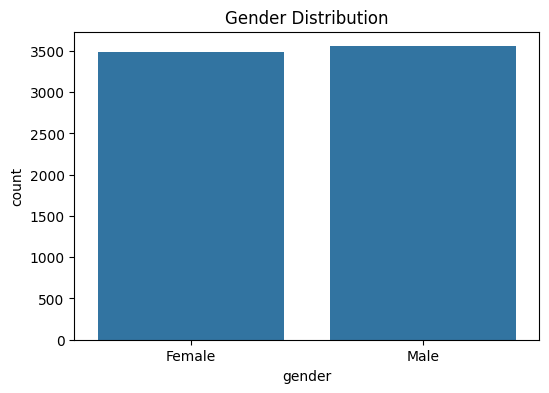

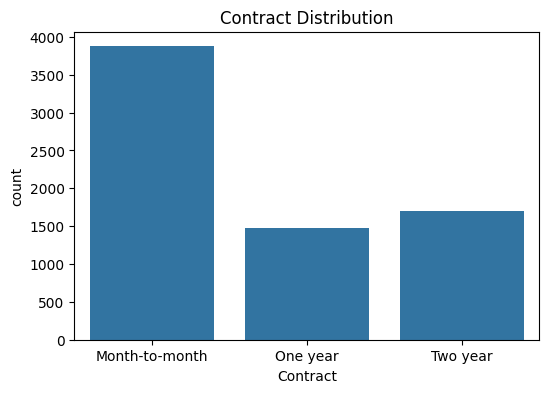

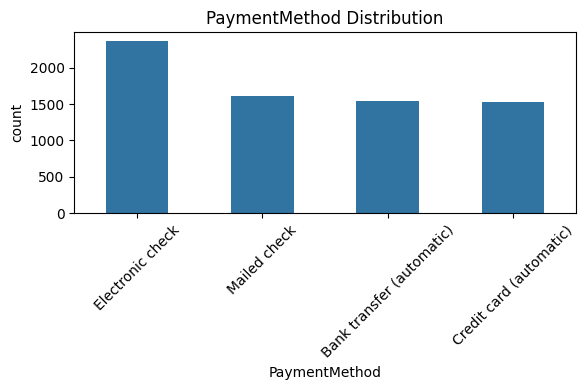

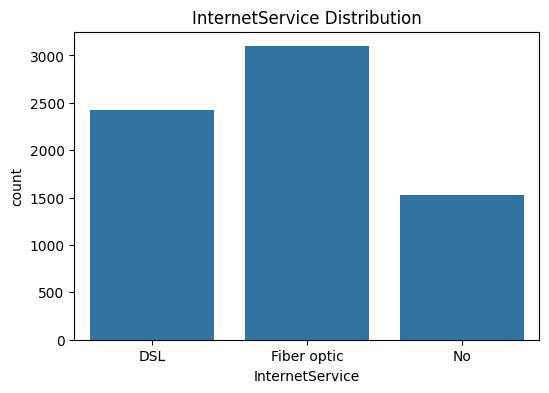

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="gender")
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Contract")
plt.title("Contract Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=data, x="PaymentMethod", width=0.5)
plt.title("PaymentMethod Distribution")
plt.xticks(rotation=45)  # rotate labels 45 degrees
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=data, x="InternetService")
plt.title("InternetService Distribution")
plt.show()

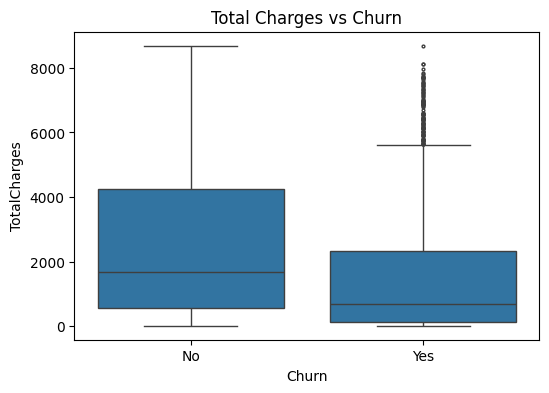

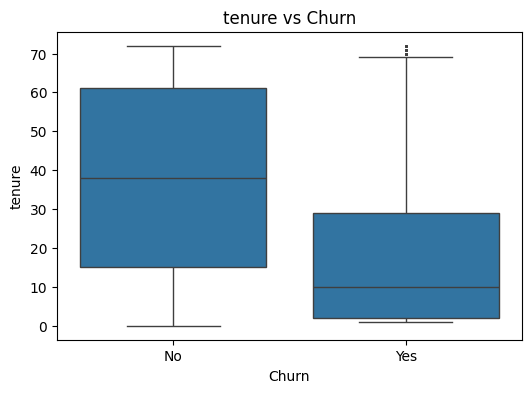

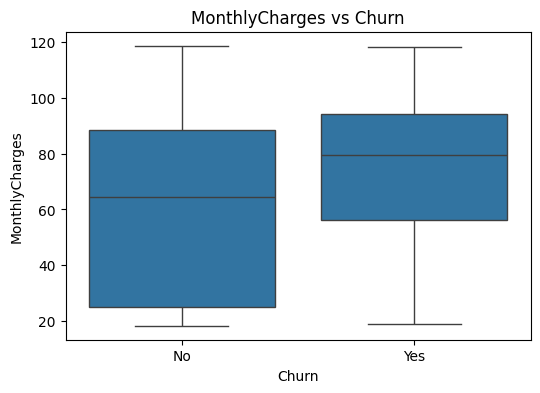

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(data=data, x="Churn", y="TotalCharges",showfliers=True, fliersize=2)
plt.title("Total Charges vs Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=data , x="Churn" , y="tenure",showfliers=True, fliersize=1)
plt.title("tenure vs Churn") 
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=data , x="Churn" , y="MonthlyCharges",showfliers=True, fliersize=1)
plt.title("MonthlyCharges vs Churn") 
plt.show()

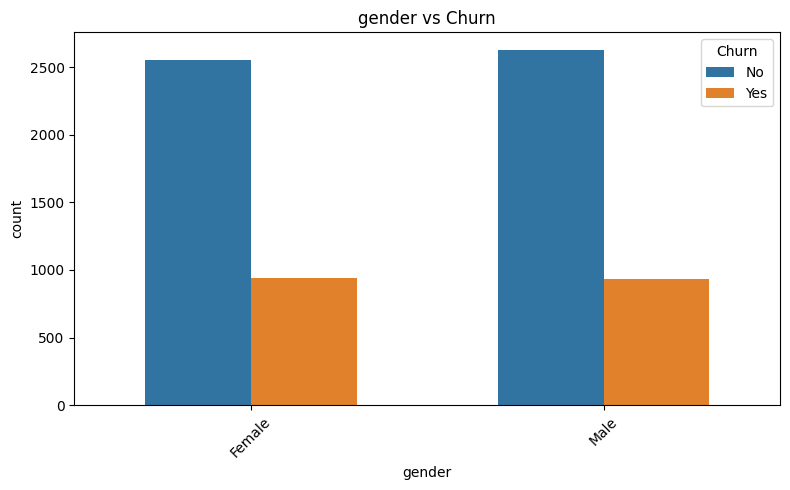

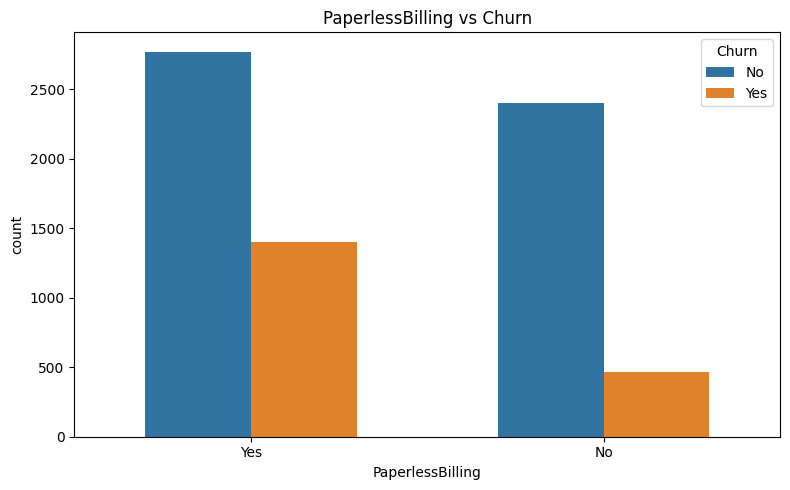

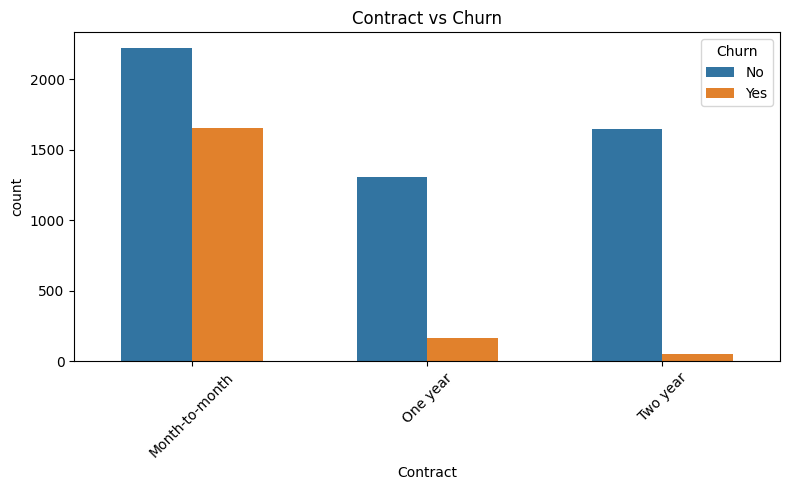

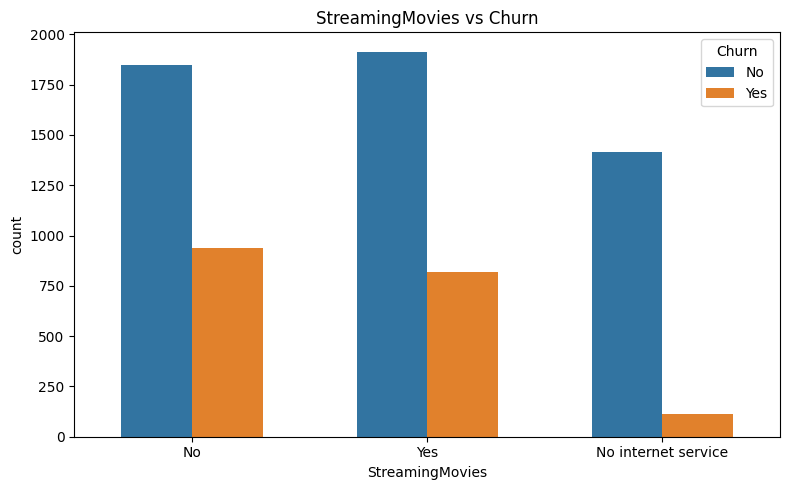

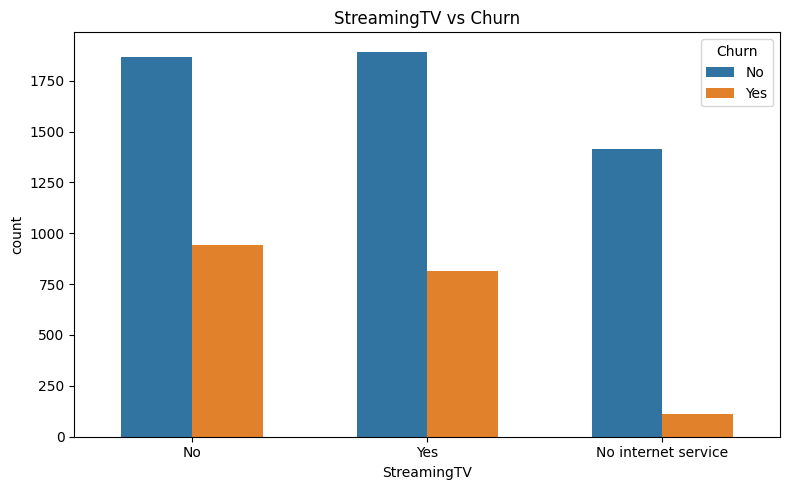

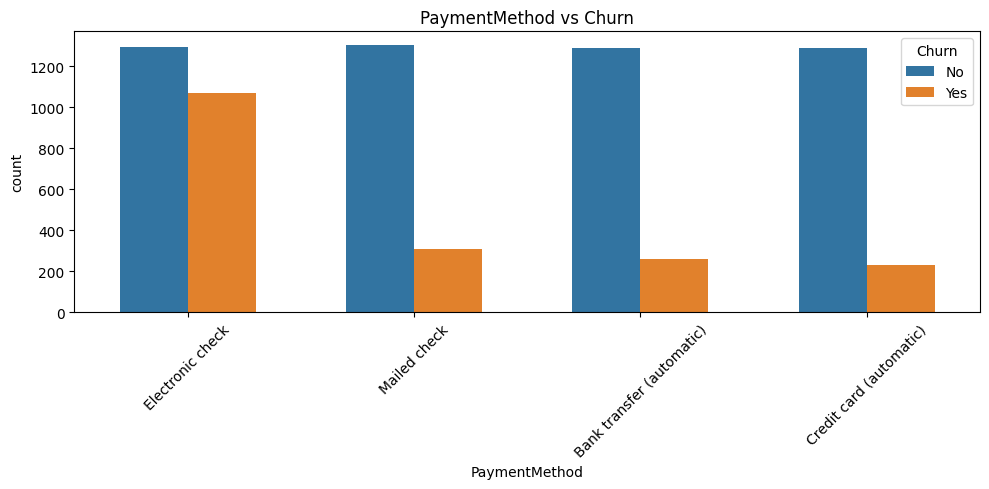

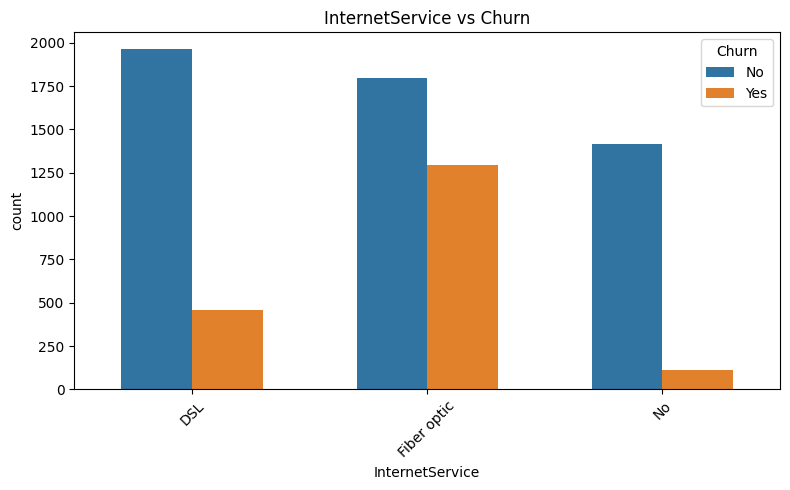

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="gender", hue="Churn", width=0.6)
plt.title("gender vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="PaperlessBilling", hue="Churn", width=0.6)
plt.title("PaperlessBilling vs Churn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Contract", hue="Churn", width=0.6)  # hue splits by target
plt.title("Contract vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="StreamingMovies", hue="Churn", width=0.6)  # hue splits by target
plt.title("StreamingMovies vs Churn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="StreamingTV", hue="Churn", width=0.6)  # hue splits by target
plt.title("StreamingTV vs Churn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=data, x="PaymentMethod", hue="Churn", width=0.6)
plt.title("PaymentMethod vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=data, x="InternetService", hue="Churn", width=0.6)
plt.title("InternetService vs Churn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


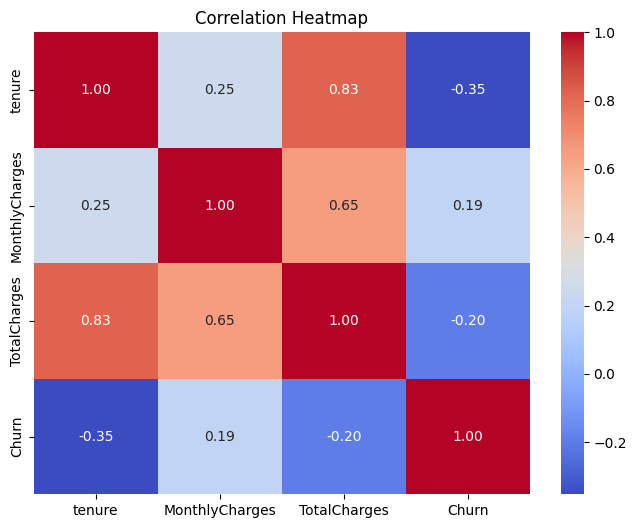

In [14]:
# Copy dataset
data_encoded = data.copy()

# Encode all categorical columns
cat_cols = data_encoded.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    data_encoded[col] = le.fit_transform(data_encoded[col])

# Compute correlation matrix
corr = data_encoded.corr()

# Filter only numeric columns if needed
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']  # Churn must be encoded


plt.figure(figsize=(8,6))
sns.heatmap(data_encoded[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

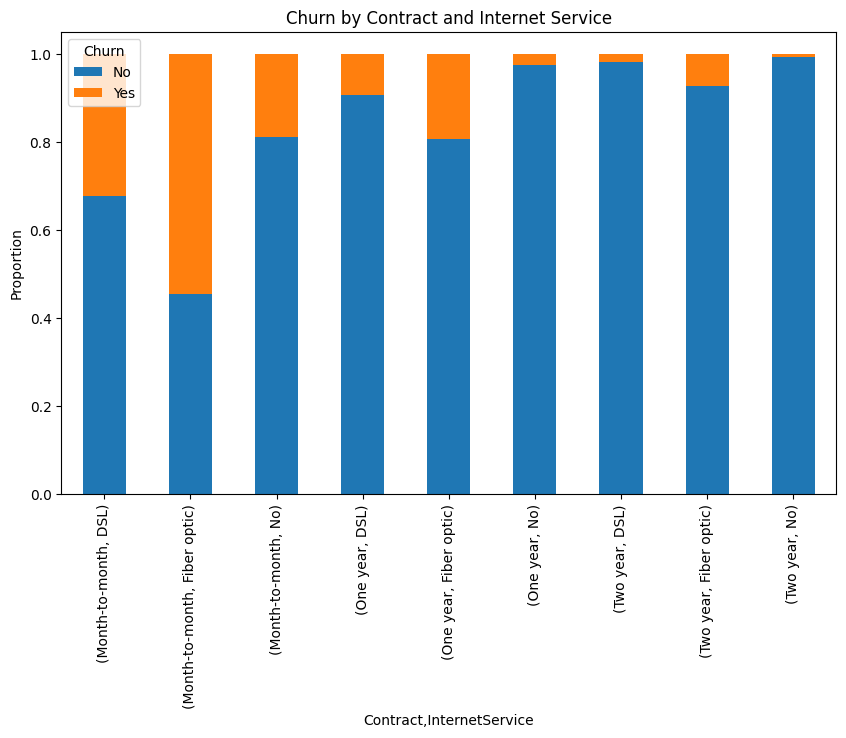

In [15]:

ct = pd.crosstab([data['Contract'], data['InternetService']], data['Churn'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Churn by Contract and Internet Service')
plt.ylabel('Proportion')
plt.show()
